# Convergence per Attack per Algorithm

In [1]:
%load_ext autoreload
import sys
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime
import copy

In [2]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2
from lib.graph_factory import GraphFactory, add_graph_plot
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed
from lib.classifier import ByzClassifier
from lib.system import SystemSimulator
from lib.config import BASE_CONF, NUM_NODES

In [4]:
# Helper Functions
fmt = lambda sec : f"{sec // 60}m {sec % 60:.2f}s"
def convert(o):
    if isinstance(o, np.generic):
        return o.item()
    raise TypeError(f'{type(o)} not serializable')

In [5]:
RUN_DIR = Path().resolve()
config = copy.deepcopy(BASE_CONF)
config['train']['b'] = 4
config['sys']['b'] = config['train']['b'] 
config['classifier_model_type'] = 'mlp'

b = config['train']['b']
config['graph_args'].update({
    'ws_k': 5,
    'ws_p': 0.1,
    'rand_reg_deg':b+1,
    'geom_radius':0.35,
    'er_p':min(1.0, 3.0 * np.log(NUM_NODES) / NUM_NODES),
})
target_pi = rng('dir','exp11').dirichlet(np.full(NUM_NODES,1))
config['graph_weights'] = 'MH_gen'
graphs = ['random-regular','watts-strogatz', 'geometric']
ATKS = ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM']
ALGS = ['RDSGD', 'ORACLE', 'IOS', 'SCC', 'TriMean', 'CooMed']
# ALGS = ['RDSGD', 'ORACLE']
# ALGS = ['RDSGD']
COLORS = dict(zip(ALGS, ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']))
clf_optimal_op_pt = {
    ('random-regular','all_atks',5) : dict(cost_fp=6.0, cost_fn=1.0), 
    ('erdos-renyi', 'all_atks',5) : dict(cost_fp=6.0, cost_fn=1.0),
    ('geometric','sign_flip',10) : dict(cost_fp=3.0, cost_fn=1.0),
    ('geometric','gaussian',10) : dict(cost_fp=1, cost_fn=2),
    ('geometric','label_flip',10): dict(cost_fp=1, cost_fn=1.2),
    ('watts-strogatz','sign_flip',5): dict(cost_fp=3, cost_fn=1),
    ('watts-strogatz','ALIE',5): dict(cost_fp=3, cost_fn=1),
    ('watts-strogatz','label_flip',5): dict(cost_fp=1, cost_fn=0.9), 
}
# for random-regular graph, for all attacks the clf_optimal_op_pt have params dict(cost_fp=6.0, cost_fn=1.0) producing optimal tau_C's

In [6]:
global_dataset = fetch_dataset('MNIST')
gf = GraphFactory(config['train']['num_nodes'], b)
proj_const_estimator = ProjConstEstimator(config, global_dataset, gf) 
clf = ByzClassifier(config, global_dataset, gf)
sys_sim = SystemSimulator(config, global_dataset, gf)

In [7]:
# Fix a graph topology and attack
config['graph_type']='erdos-renyi'
atk = 'label_flip'
RUN_ID=20
local_seed = 777

In [8]:
proj_const_estimator.configure(config, seed('proj',local_seed))
proj_const = proj_const_estimator.estimate()

In [9]:
%%time
clf_sim_data = clf.run_simulations(config, proj_const, seed('clf',local_seed))

Simulating RDSGD @ (beta_C=0.1, gamma_C=0.12)
Building training set. Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'] (seed 7027702613)
Building validation set I. Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'] (seed 4547336971)
Building validation set II. Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'] (seed 255064264627)
Building test set. Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'] (seed 89706556621)
CPU times: user 50min 24s, sys: 1min 7s, total: 51min 32s
Wall time: 4min 7s


In [10]:
%%time
config['classifier_model_type'] = 'xgb'
clf_est, clf_preproc = clf.fit(in_model='xgb')

CPU times: user 34.5 s, sys: 51.3 ms, total: 34.6 s
Wall time: 13.1 s


In [20]:
clf_op_pt = clf.calc_optimal_op_pt(cost_fp=1, cost_fn=3)
clf_metrics = clf.test()

prelim_metrics = dict()
prelim_metrics['proj_const'] = proj_const
prelim_metrics.update(clf_op_pt)
prelim_metrics.update(clf_metrics)
display(pd.DataFrame([prelim_metrics])[['C_fnr','C_fpr', 'gamma_C', 'beta_C']])

,C_fnr,C_fpr,gamma_C,beta_C
0,0.148,0.024875,0.041037,0.201259


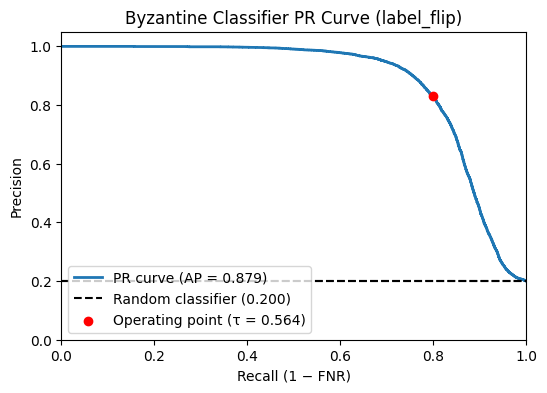

In [21]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
clf.plot_pr(ax)
ax.axhline(clf.prevalence, color='k', linestyle='--')
ax.set_title(f'Byzantine Classifier PR Curve ({atk})')
fig.savefig(f'{config['graph_type']}_b{config['sys']['b']}_{atk}_{RUN_ID}_byz_clf_pr_curve.png')
plt.show()

In [22]:
%%time
sim_params = {
    'algorithms': ALGS,
    'atk_type': atk,
    'threat_model': 'T3',
    'seed': local_seed
}
params_C = dict()

# Specifies RDSGD_ORACLE Parameters
params_C['C_fpr'] = clf_metrics['gamma_C']
params_C['C_fnr'] = clf_metrics['beta_C']

# Specifies RDSGD Parameters
params_C['C_tau'] = clf_op_pt['C_tau']

sys_sim.init_simulation(config, proj_const, clf_preproc, clf_est, params_C, seed('sys', local_seed))
df = sys_sim.simulate(sim_params)

=========================RDSGD==========================
[k=50] train_loss: [1.320,1.653],test_acc: [0.722,0.854]
[k=100] train_loss: [1.331,1.665],test_acc: [0.769,0.856]
[k=150] train_loss: [1.301,1.667],test_acc: [0.767,0.855]
=========================ORACLE=========================
[k=50] train_loss: [1.480,1.637],test_acc: [0.854,0.859]
[k=100] train_loss: [1.483,1.640],test_acc: [0.857,0.860]
[k=150] train_loss: [1.485,1.639],test_acc: [0.859,0.860]
==========================IOS===========================
[k=50] train_loss: [1.493,1.657],test_acc: [0.853,0.856]
[k=100] train_loss: [1.493,1.658],test_acc: [0.855,0.861]
[k=150] train_loss: [1.491,1.662],test_acc: [0.855,0.861]
==========================SCC===========================
[k=50] train_loss: [1.507,1.659],test_acc: [0.852,0.856]
[k=100] train_loss: [1.513,1.655],test_acc: [0.855,0.856]
[k=150] train_loss: [1.514,1.656],test_acc: [0.855,0.857]
========================TriMean=========================
[k=50] train_loss: [1.5

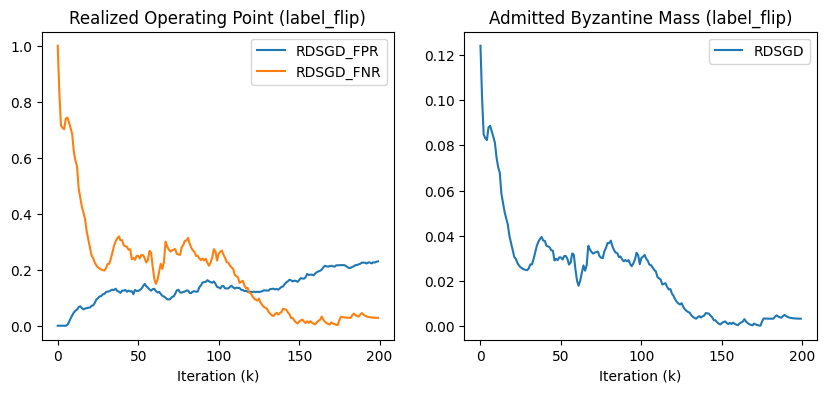

In [23]:
# Plot Realized FPR and FNR 
fig, ax = plt.subplots(1,2,figsize=(10,4))
# for idx, alg in enumerate(['RDSGD', 'ORACLE']):
for idx, alg in enumerate(['RDSGD']):
    ax[0].plot(df.loc[alg, 'gamma_k'].ewm(com=2, adjust=True).mean(), label=f'{alg}_FPR')
    ax[0].plot(df.loc[alg, 'beta_k'].ewm(com=2, adjust=True).mean(), label=f'{alg}_FNR')
    ax[1].plot(df.loc[alg, 'byz_w_k'].ewm(com=2, adjust=True).mean(), label=alg)
ax[0].set(title=f'Realized Operating Point ({atk})', xlabel='Iteration (k)', ylabel='')
ax[1].set(title=f'Admitted Byzantine Mass ({atk})', xlabel='Iteration (k)', ylabel='')
ax[0].legend()
ax[1].legend()
plt.show()
fig.savefig(f'{config['graph_type']}_{atk}_{RUN_ID}_realized_fpr_fnr.png')

In [24]:
df.to_csv(f'{config['graph_type']}_{atk}_results_dataset_{RUN_ID}.csv')

In [25]:
sim_metrics = sys_sim.log_results(config, {}, RUN_DIR, RUN_ID, logfile="logf1.csv")

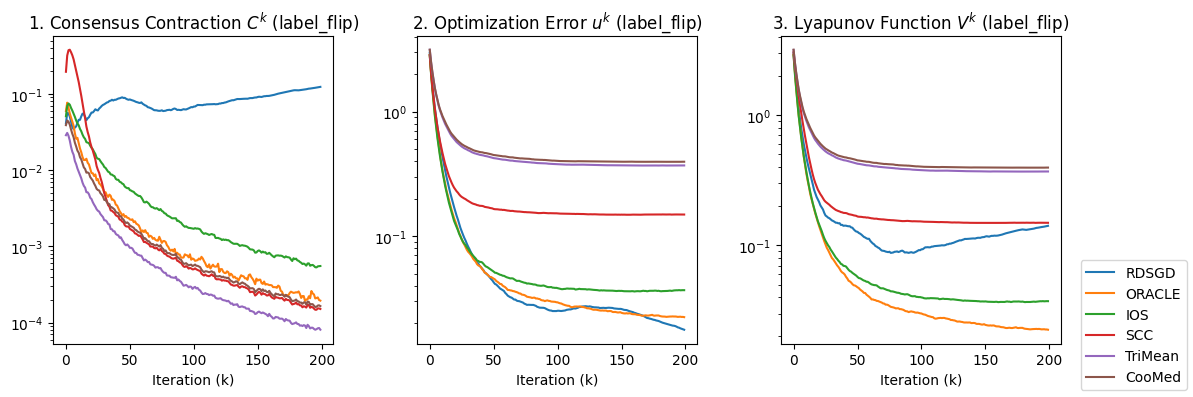

In [26]:
# Plot Lyapunov Function
fig, ax = plt.subplots(1,3,figsize=(13,4))
for alg in ALGS:
    if alg == 'RDSGD':
        gap = np.pow(df.loc['RDSGD','opt_gap_pi'],2)
        conv = df.loc['RDSGD','C_pi']
    else:
        gap = np.pow(df.loc[alg,'opt_gap'],2)
        conv = df.loc[alg,'C_unif']
    ax[0].plot(conv, label=alg, color=COLORS[alg])
    ax[1].plot(gap, color=COLORS[alg])
    ax[2].plot(conv+gap, color=COLORS[alg])
    
ax[0].set(title=f'1. Consensus Contraction $C^{{k}}$ ({atk})', xlabel='Iteration (k)', yscale='log')
ax[1].set(title=f'2. Optimization Error $u^{{k}}$ ({atk})', xlabel='Iteration (k)', yscale='log')
ax[2].set(title=f'3. Lyapunov Function $V^{{k}}$ ({atk})', xlabel='Iteration (k)', yscale='log')

fig.legend(loc='lower right')
fig.subplots_adjust(wspace=0.3)
fig.savefig(f'{config['graph_type']}_b{config['sys']['b']}_{atk}_{RUN_ID}_convergence.png')
plt.show()

In [27]:
df2 = pd.DataFrame()
# min across nodes of test accuracy at final iteration
df2['lb_node_ta'] = df['min_test_acc'].groupby(['alg']).nth(-1).groupby(['alg']).first() 

# max across nodes of test accuracy at final iteration 
df2['ub_node_ta'] = df['max_test_acc'].groupby(['alg']).nth(-1).groupby(['alg']).first() 

# mean test accuracy taken over system
ser = df['test_acc'].groupby(['alg']).agg('mean')
ser['RDSGD'] = df.loc['RDSGD','test_acc_pi'].mean()
ser['ORACLE'] = df.loc['ORACLE','test_acc_pi'].mean()
df2['sys_mta'] = ser     

In [28]:
df2.sort_values('sys_mta', inplace=True, ascending=True)
display(df2)
df2.to_csv(f'{config['graph_type']}_b{config['sys']['b']}_{atk}_{RUN_ID}_final_ta.csv')

,lb_node_ta,ub_node_ta,sys_mta
alg,,,
CooMed,0.849437,0.851948,0.847718
TriMean,0.851212,0.852944,0.849739
IOS,0.854242,0.859394,0.853824
SCC,0.854719,0.856364,0.854204
RDSGD,0.716234,0.855238,0.855202
ORACLE,0.857835,0.859567,0.856605


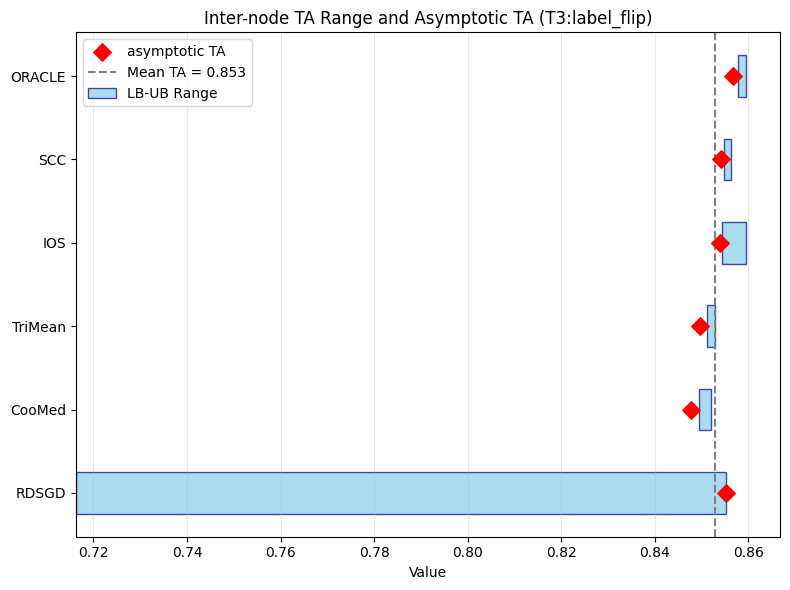

In [29]:
df2 = df2.sort_values('lb_node_ta')

fig, ax = plt.subplots(figsize=(8, 6))

y_pos = np.arange(len(df2))
bar_widths = df2['ub_node_ta'] - df2['lb_node_ta']
ax.barh(y_pos, width=bar_widths, left=df2['lb_node_ta'],height=0.5, 
        color='skyblue', edgecolor='navy', alpha=0.7, label='LB-UB Range')

ax.scatter(df2['sys_mta'], y_pos, color='red', marker='D', s=80,label='asymptotic TA', zorder=5)

ref_line = df2['sys_mta'].mean()
ax.axvline(x=ref_line, color='gray', linestyle='--', linewidth=1.5, label=f'Mean TA = {ref_line:.3f}')

ax.set_yticks(y_pos)
ax.set_yticklabels(df2.index)
ax.set_xlabel('Test Accuracy')
ax.set_xlabel('Value')
ax.set_title(f'Inter-node TA Range and Asymptotic TA (T3:{atk})')
ax.legend()
ax.grid(axis='x', alpha=0.3)
fig.savefig(f'{config['graph_type']}_b{config['sys']['b']}_{atk}_{RUN_ID}_ta_range_comparison.png')
plt.tight_layout()
plt.show()

In [30]:
payload = copy.deepcopy(config)
del payload['graph_args']['MH_target_pi']
config.update(prelim_metrics)
with open(f'{payload['graph_type']}_b{payload['sys']['b']}_{atk}_{RUN_ID}_config.json', 'w') as f:
    json.dump(payload, f, indent=2, default=convert)